##In this notebook, we simulate illustrate rainfall-runoff UQ plot for 1 CAMELS-FR catchment. Similar work can be conducted on other catchments.

# IMPORT LIBRARIES

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

In [ ]:
from google.colab import drive

# Monter Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##CAMELS-DATA from my Google Drive.

In [ ]:
!pip install git+https://github.com/kratzert/RRMPG.git

  Cloning https://github.com/kratzert/RRMPG.git to /tmp/pip-req-build-lm3lbkuf
  Running command git clone --filter=blob:none --quiet https://github.com/kratzert/RRMPG.git /tmp/pip-req-build-lm3lbkuf
  Resolved https://github.com/kratzert/RRMPG.git to commit 7de78c25acc1c255d2acaf739d65e9ce7bbd60c3
  Preparing metadata (setup.py) ... done


In [ ]:
pip install aqua-fetch

In [ ]:
from aqua_fetch import RainfallRunoff

rr = RainfallRunoff("CAMELS_FR")

/usr/local/lib/python3.12/dist-packages/aqua_fetch/rr/utils.py:127: UserWarning: netCDF4 module is not installed. Please install it to save data in netcdf format
  warnings.warn(msg, UserWarning)



        Not downloading the data since the directory 
        /usr/local/lib/python3.12/dist-packages/aqua_fetch/data/CAMELS/CAMELS_FR already exists.
        Use overwrite=True to remove previously saved files and download again
P392252001  not found in site_general_attributes.csv
P613402001  not found in site_general_attributes.csv


In [ ]:
meta, ds = rr.fetch()

Read 654 stations for 22 dyn features in 76.01 seconds with 2 cpus.


In [ ]:
import xarray as xr

print(ds)              # aperçu global
#print(ds.coords)       # coordonnées (temps, variables, stations)
#print(ds['912101A'].head())  # exemple : station 5

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 18993, dynamic_features: 22)
Coordinates:
  * time              (time) datetime64[ns] 152kB 1970-01-01 ... 2021-12-31
  * dynamic_features  (dynamic_features) object 176B 'q_cms_obs' ... 'airtemp...
Data variables: (12/654)
    A105003001        (time, dynamic_features) float64 3MB 1.65e+03 ... 13.4
    A107020001        (time, dynamic_features) float64 3MB nan nan ... 4.1 13.3
    A112020001        (time, dynamic_features) float64 3MB 1.04e+03 ... 13.4
    A116003002        (time, dynamic_features) float64 3MB nan nan ... 4.3 13.3
    A140202001        (time, dynamic_features) float64 3MB nan nan ... 6.8 12.4
    A202030001        (time, dynamic_features) float64 3MB nan nan ... 7.1 13.2
    ...                ...
    Y661401001        (time, dynamic_features) float64 3MB 860.0 0.441 ... 14.3
    Y781000101        (time, dynamic_features) float64 3MB nan nan ... 6.4 15.8
    Y862000101        (time, dynamic_features) float64 3MB 

In [ ]:
print(ds.dynamic_features.values)

['q_cms_obs' 'q_mm_obs' 'tsd_val_s' 'tsd_val_q' 'tsd_val_m' 'tsd_val_c'
 'tsd_val_i' 'pcp_mm' 'pcp_mm_solfrac' 'airtemp_C_mean' 'pet_mm_ou'
 'pet_mm_pe' 'pet_mm_pm' 'windspeed_mps' 'spechum_gkg' 'lwdownrad_wm2'
 'solrad_wm2' 'tsd_swi_gr' 'tsd_swi_isba' 'tsd_swe_isba' 'airtemp_C_min'
 'airtemp_C_max']


In [ ]:
# Full period
print(ds["time"].values[0], ds["time"].values[-1])

1970-01-01T00:00:00.000000000 2021-12-31T00:00:00.000000000


## Period used

In [ ]:
# Period used
ds_recent = ds.sel(time=slice("2000-01-01", "2021-12-31"))

# List of all stations
all_stations = list(ds_recent.keys())

# Selection of features of interest
features = ["q_mm_obs", "pcp_mm", "pet_mm_pm"]

# Count stations without NaN
valid_stations = []

for station_id in all_stations:
    subset = ds_recent[station_id].sel(dynamic_features=features)
    df = subset.to_dataframe().reset_index().pivot(
        index="time", columns="dynamic_features", values=station_id
    )

    if df[features].isna().sum().max() == 0:  # no missing values
        valid_stations.append(station_id)

#Basin K066331001

GRHyMoLAP

In [ ]:
import numpy as np
from scipy.optimize import minimize
from numba import njit

# ============================================
# NUMBA FUNCTIONS
# ============================================

@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    Perc = np.zeros(n)

    S[0] = X1 / 2.0
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))

    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2

        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))

        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))

        S[i] = S[i-1] + Ps - Es

        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))

        S[i] -= Perc[i]

    return Perc


@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)

    Q = np.zeros(N)
    Q[0] = Q0

    Perc = Percolation(Pn, En, X1)

    for t in range(N-1):
        Q[t+1] = max(
            0.0,
            Q[t] - (MU / LAMBDA) * (Q[t])**(2*MU - 1)
            + GAMMA * Perc[t+1] * Pn[t+1]
        )

    return Q


@njit
def NSE(obs, sim):
    n = len(obs)
    mean_obs = 0.0
    count = 0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i]) ** 2
            den += (obs[i] - mean_obs) ** 2

    if den == 0:
        return np.nan

    return 1.0 - num / den


@njit
def RMSE(obs, sim):
    n = len(obs)
    mse = 0.0
    count = 0

    for i in range(n):
        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1

    if count == 0:
        return np.nan

    return np.sqrt(mse / count)


# ============================================
# OBJECTIVE (minimize RMSE)
# ============================================
def objective(params, Q0, Pn_train, En_train, Q_obs_train):
    Q_sim = GRHyMoLAP_Model(np.array(params), Q0, Pn_train, En_train)
    rmse = RMSE(Q_obs_train, Q_sim)
    return rmse if np.isfinite(rmse) else 1e9


# ============================================
# General parameters
# ============================================
b1_ratio = 0.6
max_missing_ratio = 0.05

stations = ['K066331001']
results = {}

# ============================================
# Main loop
# ============================================
i = 0
for station_id in stations:
    i += 1
    print(f"\n=== Station {station_id} ===, Number = {i}")

    Q_obs = ds_recent[station_id].sel(dynamic_features="q_mm_obs").to_numpy()
    P     = ds_recent[station_id].sel(dynamic_features="pcp_mm").to_numpy()
    PET   = ds_recent[station_id].sel(dynamic_features="pet_mm_pm").to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        print("⚠️ Station skipped (no valid data).")
        continue

    missing_count = np.sum(np.isnan(Q_obs))
    missing_ratio = missing_count / N
    if missing_ratio > max_missing_ratio:
        print(f"⚠️ Too many missing values ({missing_ratio*100:.1f}%)")
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    # ============================================
    # Optimization (multi-start)
    # ============================================
    initial_guesses = [
        [1.0, 8, 150, 0.1],
        [0.6, 2, 400, 1],
        [1.4, 15, 300, 0.5],
        [1., 10, 1000, 0.3],
        [1.8, 5, 800, 0.5]
    ]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:
        res = minimize(
            objective,
            guess,
            args=(Q0, Pn[:b1], En[:b1], Q_obs[:b1]),
            method="Nelder-Mead",
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA, X1, GAMMA = best_res.x
    RMSE_cal = best_res.fun
    NSE_cal = NSE(Q_obs[:b1], GRHyMoLAP_Model(best_res.x, Q0, Pn[:b1], En[:b1]))

    # ============================================
    # Full simulation
    # ============================================
    Qsim = GRHyMoLAP_Model(
        np.array([MU, LAMBDA, X1, GAMMA]),
        Q0, Pn, En
    )

    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    print(f"✅ Calibration RMSE: {RMSE_cal:.3f}, Validation RMSE: {RMSE_val:.3f}")
    print(f"   Calibration NSE: {NSE_cal:.3f}, Validation NSE: {NSE_val:.3f}")
    print(f"   Params: mu={MU:.3f}, lambda={LAMBDA:.3f}, X1={X1:.3f}, GAMMA={GAMMA:.3f}")

    Perc = Percolation(Pn, En, X1)

    results[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,
        "Qsim": Qsim,
        "Perc": Perc,
        "Pn": Pn,
        "Q_obs": Q_obs,
        "missing_ratio": missing_ratio,
        "missing_count": missing_count,
    }

print(f"\n✅ Simulation completed for {len(results)} valid basins.")


=== Station K066331001 ===, Number = 1
✅ Calibration RMSE: 0.762, Validation RMSE: 0.503
   Calibration NSE: 0.747, Validation NSE: 0.771
   Params: mu=1.113, lambda=8.072, X1=234.620, GAMMA=0.194

✅ Simulation completed for 1 valid basins.


# SDE

In [ ]:
import numpy as np

# ----------------------------
# Parameters
# ----------------------------
basin_id = 'K066331001'   # target basin
res = results[basin_id]

MU, LAMBDA, X1, GAMMA = res["params"]

Q_obs = res["Q_obs"]
Pn = res["Pn"]
Perc = res["Perc"]

n_traj = 5000  # number of Monte Carlo trajectories
b1_ratio = 0.6  # fraction for calibration
b1 = int(len(Q_obs) * b1_ratio)  # calibration/validation split

# Diffusion types to test
diffusions = ['Pn', 'Perc', 'Q', 'PnPerc']

sigma_results = {}
simulation_results = {}

# ----------------------------
# Loop over diffusions
# ----------------------------
for diff in diffusions:

    # --- Estimate sigma on calibration period ---
    numerator = 0.0
    denominator = 0.0

    for k in range(b1-1):
        if np.isnan(Q_obs[k+1]) or np.isnan(Q_obs[k]):
            continue

        # Deterministic drift term
        drift = - (MU / LAMBDA) * Q_obs[k]**(2*MU - 1) + GAMMA * Perc[k+1] * Pn[k+1]

        # Select diffusion term
        if diff == 'Pn':
            diff_term = Pn[k+1]
        elif diff == 'Perc':
            diff_term = Perc[k+1]
        elif diff == 'Q':
            diff_term = Q_obs[k]
        elif diff == 'PnPerc':
            diff_term = Pn[k+1] * Perc[k+1]

        # Increment
        incr = Q_obs[k+1] - Q_obs[k] - drift
        numerator += incr**2
        denominator += diff_term**2

    sigma = np.sqrt(numerator / denominator) if denominator > 0 else np.nan
    sigma_results[diff] = sigma
    res[f"sigma_{diff}"] = sigma
    print(f"Basin {basin_id}, diffusion {diff}: sigma = {sigma:.4f}")

    # ----------------------------
    # SDE Simulation
    # ----------------------------
    size_calib = b1
    size_valid = len(Q_obs) - b1

    QQ_calib = np.zeros((size_calib, n_traj))
    QQ_valid = np.zeros((size_valid, n_traj))

    # --- Calibration
    for i in range(n_traj):
        S = np.zeros(size_calib)
        S[0] = Q_obs[0]
        for k in range(size_calib-1):
            drift = - (MU / LAMBDA) * S[k]**(2*MU - 1) + GAMMA * Perc[k+1] * Pn[k+1]

            if diff == 'Pn':
                diff_term = Pn[k+1]
            elif diff == 'Perc':
                diff_term = Perc[k+1]
            elif diff == 'Q':
                diff_term = S[k]
            elif diff == 'PnPerc':
                diff_term = Pn[k+1] * Perc[k+1]

            diffusion = sigma * diff_term * np.random.normal(0.0, 1.0)
            S[k+1] = max(0, S[k] + drift + diffusion)
        QQ_calib[:, i] = S.copy()

    # --- Validation
    for i in range(n_traj):
        S = np.zeros(size_valid)
        S[0] = QQ_calib[-1, i]  # last calibration value as initial state
        for k in range(size_valid-1):
            drift = - (MU / LAMBDA) * S[k]**(2*MU - 1) + GAMMA * Perc[b1+k+1] * Pn[b1+k+1]

            if diff == 'Pn':
                diff_term = Pn[b1+k+1]
            elif diff == 'Perc':
                diff_term = Perc[b1+k+1]
            elif diff == 'Q':
                diff_term = S[k]
            elif diff == 'PnPerc':
                diff_term = Pn[b1+k+1] * Perc[b1+k+1]

            diffusion = sigma * diff_term * np.random.normal(0.0, 1.0)
            S[k+1] = max(0, S[k] + drift + diffusion)
        QQ_valid[:, i] = S.copy()

    simulation_results[diff] = {
        "QQ_calib": QQ_calib,
        "QQ_valid": QQ_valid
    }

Basin K066331001, diffusion Pn: sigma = 0.1400
Basin K066331001, diffusion Perc: sigma = 2.3629
Basin K066331001, diffusion Q: sigma = 0.4926
Basin K066331001, diffusion PnPerc: sigma = 0.2571


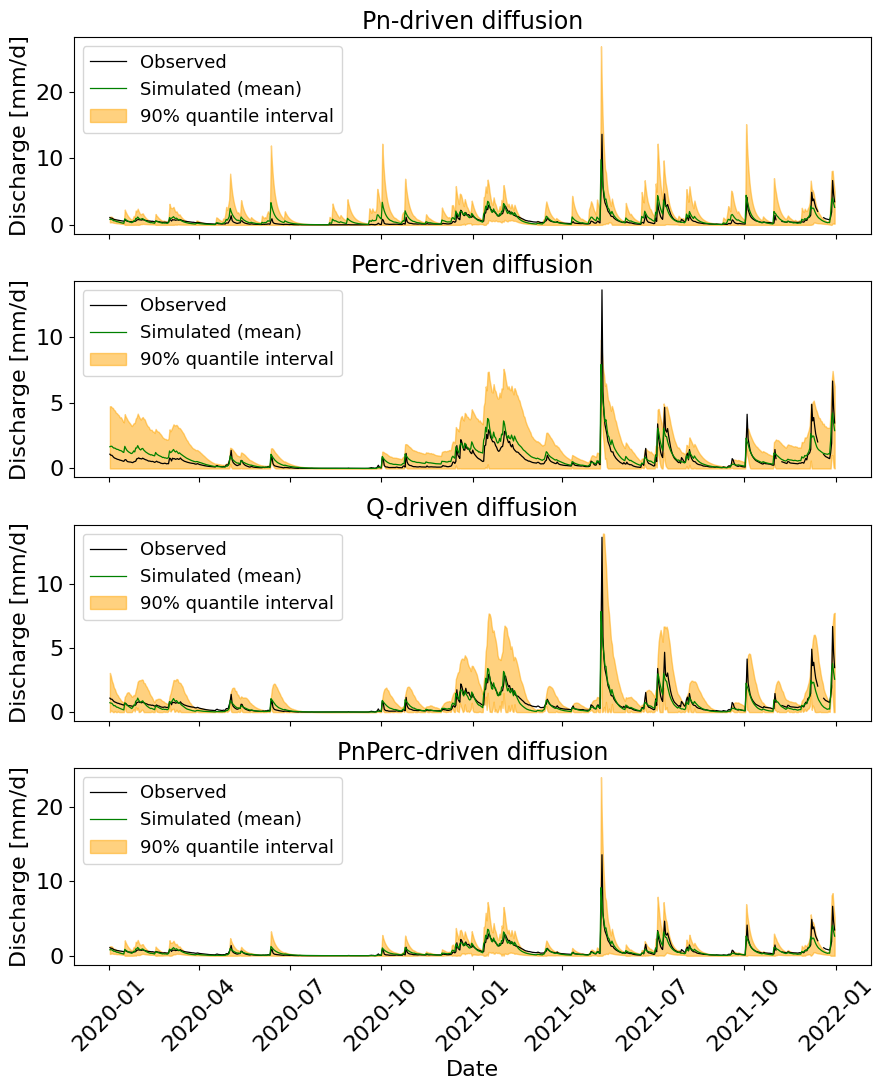

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

start_date = "2000-01-01"
# ----------------------------
# IS function
# ----------------------------
def interval_score(Q, L, U, alpha=0.1):
    IS = (U - L) + (2/alpha) * np.maximum(L - Q, 0) + (2/alpha) * np.maximum(Q - U, 0)
    return np.mean(IS)

# ----------------------------
# Settings
# ----------------------------
basin_id = 'K066331001'
diffusions = ['Pn', 'Perc', 'Q', 'PnPerc']
n_days_to_plot = 365*2  # last 2 years

res = results[basin_id]

# Validation start index
b1 = int(len(res["Q_obs"]) * 0.6)
Q_valid_full = res["Q_obs"][b1:]  # full validation

# Dates for validation
start_date_val = pd.to_datetime(start_date) + pd.Timedelta(days=b1)
time_full = pd.date_range(start=start_date_val, periods=len(Q_valid_full))

# ----------------------------
# Figure 4x1
# ----------------------------
fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

for ax, diff in zip(axes, diffusions):
    QQv = simulation_results[diff]["QQ_valid"]  # shape: (time, n_traj)

    # Limit to last 2 years
    Q_valid = Q_valid_full[-n_days_to_plot:]
    QQv_plot = QQv[-n_days_to_plot:, :]

    # Monte Carlo statistics
    mean_Q = np.mean(QQv_plot, axis=1)
    lower = np.percentile(QQv_plot, 5, axis=1)
    upper = np.percentile(QQv_plot, 95, axis=1)

    # Dates for plotting
    time_val = time_full[-n_days_to_plot:]

    # Plot lines
    ax.plot(time_val, Q_valid, 'k', linewidth=0.9, label='Observed')
    ax.plot(time_val, mean_Q, 'g', linewidth=0.9, label='Simulated (mean)')
    ax.fill_between(time_val, lower, upper, color='orange', alpha=0.5, label='90% quantile interval')

    # Labels & title (larger fonts)
    ax.set_ylabel("Discharge [mm/d]", fontsize=16)
    ax.set_title(f"{diff}-driven diffusion", fontsize=17)

    # Larger tick labels
    ax.tick_params(axis='both', labelsize=16)

    # Legend with larger font
    ax.legend(loc='upper left', fontsize=13)

# X-axis label only at the bottom (larger font)
axes[-1].set_xlabel("Date", fontsize=16)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("UQ5.jpeg", format='jpeg', dpi=700)
#files.download("UQ5.jpeg")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

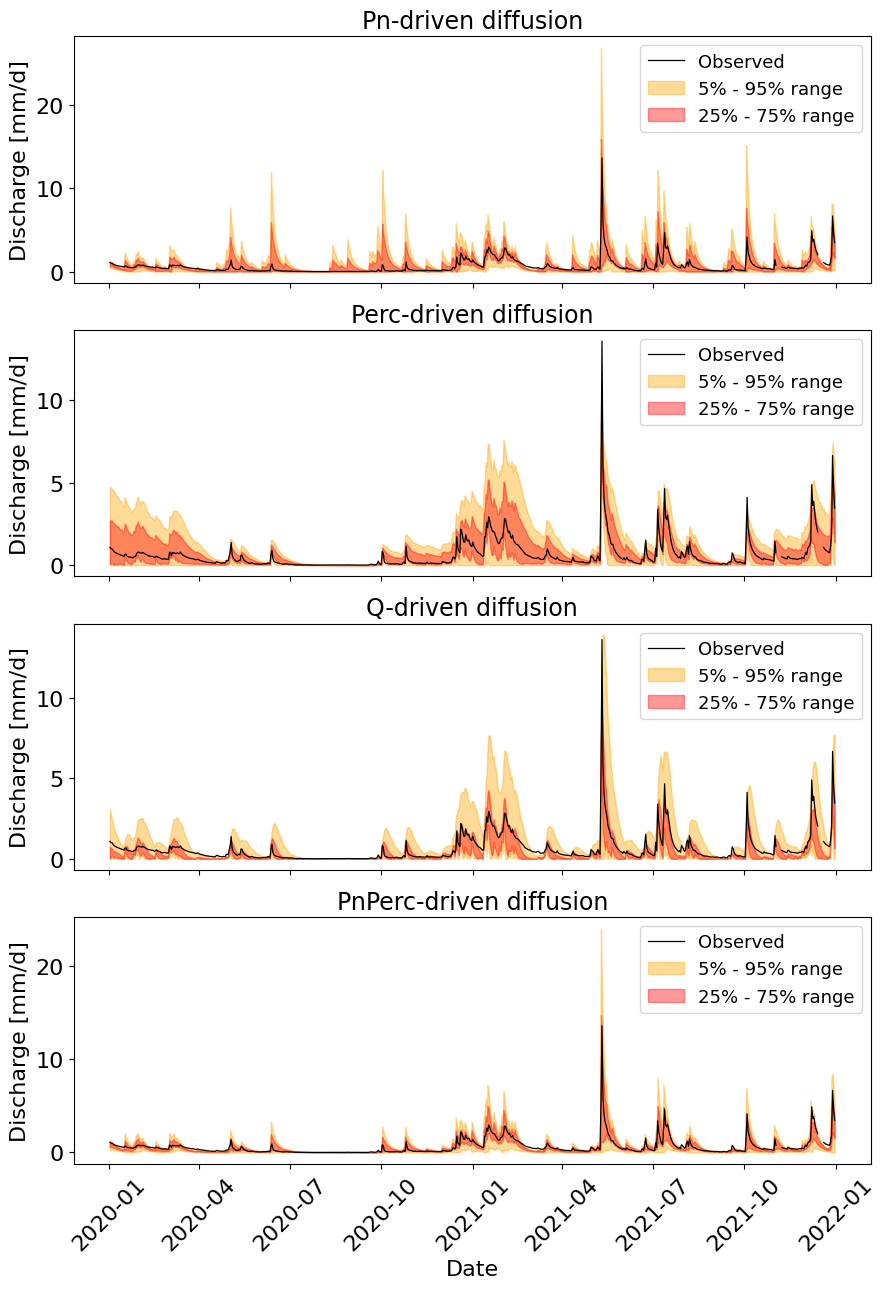

In [ ]:
start_date = "2000-01-01"

# ----------------------------
# IS function
# ----------------------------
def interval_score(Q, L, U, alpha=0.1):
    IS = (U - L) + (2/alpha) * np.maximum(L - Q, 0) + (2/alpha) * np.maximum(Q - U, 0)
    return np.mean(IS)

# ----------------------------
# Settings
# ----------------------------
basin_id = 'K066331001'
diffusions = ['Pn', 'Perc', 'Q', 'PnPerc']
n_days_to_plot = 365*2  # last 2 years

res = results[basin_id]

# Validation start index
b1 = int(len(res["Q_obs"]) * 0.6)
Q_valid_full = res["Q_obs"][b1:]

# Dates for validation
start_date_val = pd.to_datetime(start_date) + pd.Timedelta(days=b1)
time_full = pd.date_range(start=start_date_val, periods=len(Q_valid_full))

# ----------------------------
# Figure 4x1
# ----------------------------
fig, axes = plt.subplots(4, 1, figsize=(9, 13), sharex=True)

for ax, diff in zip(axes, diffusions):

    QQv = simulation_results[diff]["QQ_valid"]

    # Limit to last 2 years
    Q_valid = Q_valid_full[-n_days_to_plot:]
    QQv_plot = QQv[-n_days_to_plot:, :]

    # Monte Carlo statistics
    mean_Q = np.mean(QQv_plot, axis=1)

    # 90% interval
    lower90 = np.percentile(QQv_plot, 5, axis=1)
    upper90 = np.percentile(QQv_plot, 95, axis=1)

    # 50% interval
    lower50 = np.percentile(QQv_plot, 25, axis=1)
    upper50 = np.percentile(QQv_plot, 75, axis=1)

    # Dates
    time_val = time_full[-n_days_to_plot:]

    # Plot
    ax.plot(time_val, Q_valid, 'k', linewidth=0.9, label='Observed')
    #ax.plot(time_val, mean_Q, 'g', linewidth=0.9, label='Simulated (mean)')

    # 90% UQ (orange)
    ax.fill_between(time_val, lower90, upper90,
                    color='orange', alpha=0.4,
                    label='5% - 95% range')

    # 50% UQ (red)
    ax.fill_between(time_val, lower50, upper50,
                    color='red', alpha=0.4,
                    label='25% - 75% range')

    ax.set_ylabel("Discharge [mm/d]", fontsize=16)
    ax.set_title(f"{diff}-driven diffusion", fontsize=17)
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(loc='upper right', fontsize=13)

axes[-1].set_xlabel("Date", fontsize=16)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("range2.jpeg", format='jpeg', dpi=700)
#files.download("range2.jpeg")
plt.show()